# 🎯 Müşteri Segmentasyonu — K-Means Kümeleme

**🇹🇷 Türkçe:**
Bu notebook, `Annual_Income` ve `Spending_Score` olmak üzere iki özellikten oluşan sentetik bir müşteri veri setinde (1.499 satır) **K-Means** ile denetimsiz kümeleme yapıyor. Amaç, herhangi bir etiket olmadan müşterileri gelir/harcama davranışına göre doğal gruplara ayırmak.

Odak noktası sadece `KMeans.fit()` çağırmak değil: doğru küme sayısını (k) seçmek için **dirsek yöntemi (elbow method / WCSS)**, `kneed` kütüphanesiyle bu dirseği otomatik tespit etmek, ve **silüet skoru (silhouette score)** ile sonucu bağımsız olarak doğrulamak — bu iki yöntemin birbirini tutup tutmadığını görmek.

**🇬🇧 English:**
This notebook performs unsupervised **K-Means** clustering on a synthetic customer dataset (1,499 rows) with two features: `Annual_Income` and `Spending_Score`. The goal is to group customers by income/spending behavior with no labels at all.

The focus isn't just calling `KMeans.fit()`: choosing the right number of clusters (k) via the **elbow method (WCSS)**, detecting that elbow automatically with the `kneed` library, and independently confirming the result with the **silhouette score** — checking whether the two methods actually agree.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme (`pandas`, `numpy`) ve görselleştirme (`matplotlib`, `seaborn`) için gerekli kütüphaneler yükleniyor.

**🇬🇧 English:**
Loading the libraries needed for data handling (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
`26-customer_data.csv` okunuyor: 1.499 müşteri, sadece iki sayısal kolon (`Annual_Income`, `Spending_Score`). Etiket (target) yok — bu denetimsiz bir problem.

**🇬🇧 English:**
`26-customer_data.csv` is loaded: 1,499 customers, only two numeric columns (`Annual_Income`, `Spending_Score`). There is no label — this is an unsupervised problem.

In [2]:
df = pd.read_csv("../../Data/26-customer_data.csv")

## 🔍 2. Veriye İlk Bakış / First Look at the Data

**🇹🇷 Türkçe:**
`head()`, `info()` ve `describe()` ile veri inceleniyor: 1.499 satır, eksik değer yok. İki kolon da negatif değerler içeriyor (`Annual_Income`: -10.7 ile 10.1 arası, `Spending_Score`: -13.0 ile -1.8 arası) — bu, verinin sentetik/önceden ölçeklenmiş olduğunu düşündürüyor, gerçek dünyada "gelir" veya "harcama skoru" negatif olmaz.

**🇬🇧 English:**
The data is inspected with `head()`, `info()`, and `describe()`: 1,499 rows, no missing values. Both columns contain negative values (`Annual_Income`: -10.7 to 10.1, `Spending_Score`: -13.0 to -1.8) — suggesting the data is synthetic/pre-scaled, since real-world "income" or "spending score" wouldn't go negative.

In [3]:
df.head()

,Annual_Income,Spending_Score
0,-5.772478,-4.818216
1,6.768246,-5.424570
2,5.796159,-6.239967
3,7.096022,-5.272612
4,-5.725561,-9.316889


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   1499 non-null   float64
 1   Spending_Score  1499 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


In [5]:
df.describe()

,Annual_Income,Spending_Score
count,1499.000000,1499.000000
mean,-1.858568,-6.633932
std,6.895124,2.608376
min,-10.709274,-12.978282
25%,-7.316109,-9.264460
50%,-5.237149,-5.940883
75%,6.995162,-4.513904
max,10.056333,-1.820017


## 📊 3. Ham Veri Görselleştirmesi / Raw Data Visualization

**🇹🇷 Türkçe:**
`Annual_Income` ve `Spending_Score` bir saçılım grafiğinde (scatter plot) çiziliyor — bu, kaç doğal grup (küme) görünür olduğuna dair ilk sezgisel fikri veriyor, ileride seçilecek k değeriyle karşılaştırmak için.

**🇬🇧 English:**
`Annual_Income` and `Spending_Score` are plotted on a scatter plot — giving a first visual sense of how many natural groups (clusters) are visible, to compare against the k value chosen later.

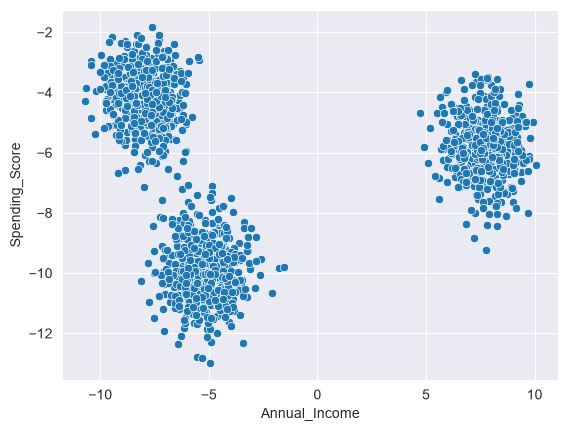

In [6]:
sns.scatterplot(data=df, x="Annual_Income", y="Spending_Score")
plt.show()

## ✂️ 4. Train/Test Ayrımı / Train/Test Split

**🇹🇷 Türkçe:**
Veri %80 eğitim / %20 test olarak bölünüyor. Denetimli problemlerin aksine burada `y` yok — `train_test_split` doğrudan `df`'e uygulanıyor, çünkü kümeleme (clustering) bir etiket tahmin etmiyor, veri noktalarını birbirine olan benzerliğine göre gruplandırıyor.

**🇬🇧 English:**
The data is split 80% train / 20% test. Unlike supervised problems, there's no `y` here — `train_test_split` is applied directly to `df`, since clustering doesn't predict a label, it groups data points by similarity to each other.

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=15)

In [9]:
X_train.head()

,Annual_Income,Spending_Score
258,7.809992,-5.031123
195,7.769519,-6.059915
817,-8.529586,-4.853877
820,-5.765759,-9.822013
716,-7.932068,-4.882406


## ⚖️ 5. Özellik Ölçekleme / Feature Scaling

**🇹🇷 Türkçe:**
K-Means, öklid uzaklığına (Euclidean distance) dayandığı için ölçeksiz özellikler yanıltıcı sonuç verir — daha geniş aralıklı bir kolon kümeleme sonucuna haksız yere baskın gelir. `MinMaxScaler`, **sadece `X_train` üzerinde** `fit` ediliyor (istatistikler eğitim setinden öğreniliyor) ve hem `X_train` hem `X_test` bu istatistiklerle dönüştürülüyor — test setine ait bilginin sızmasını (data leakage) önlemek için standart pratik.

**🇬🇧 English:**
Since K-Means relies on Euclidean distance, unscaled features distort the result — a wider-range column would unfairly dominate the clustering. `MinMaxScaler` is fit **only on `X_train`** (statistics are learned from the training set), and both `X_train` and `X_test` are transformed with those statistics — standard practice to avoid leaking test-set information.

In [10]:
from sklearn.preprocessing import MinMaxScaler

In [11]:
scaler = MinMaxScaler()

In [12]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 📈 6. Dirsek Yöntemi (Elbow Method) / Elbow Method

**🇹🇷 Türkçe:**
Doğru k değerini seçmek için k=1'den 10'a kadar her biri için `KMeans` eğitiliyor ve **WCSS** (Within-Cluster Sum of Squares, `kmeans.inertia_`) kaydediliyor. WCSS, k arttıkça monoton azalır (daha çok küme = her noktaya daha yakın bir merkez); "dirsek" noktası, azalmanın belirgin şekilde yavaşladığı yerdir ve iyi bir k adayını işaret eder. Burada k=1→2 arası WCSS 64.838'den 10.416'ya, k=2→3 arası 10.416'dan 2.296'ya düşüyor — sonrasında düşüş çok daha yumuşuyor, bu da k=3 civarında bir dirseğe işaret ediyor.

**⚠️ Dürüst bir not — tutarsız ölçekleme:** Bu döngüdeki `kmeans.fit(X_train)` çağrısı, notebook'un geri kalanının aksine **ölçeklenmemiş** `X_train`'i kullanıyor (`X_train_scaled` değil). Yani WCSS eğrisi ham (ölçeksiz) verilerden hesaplanıyor, ama birazdan asıl kümeleme modeli `X_train_scaled` ile eğitiliyor — iki adım birbiriyle tutarsız. Bu, sonucu **geçersiz kılmıyor** (aşağıdaki silüet skoru analizi, ölçeklenmiş veri üzerinde bağımsız olarak yine k=3'ü en iyi seçim olarak doğruluyor) ama tesadüf: `MinMaxScaler` her iki kolonu da tekdüze (monotonik) şekilde küçültüyor olsa da, iki kolonu **farklı oranlarda** ölçeklediği için (biri [-10.7, 10.1], diğeri [-13.0, -1.8] aralığında), ölçeklenmiş uzayda hangi noktaların birbirine "yakın" sayıldığı ölçeklenmemiş uzaydakinden farklı olabilir.

**🇬🇧 English:**
To choose the right k, `KMeans` is trained for each value from k=1 to 10, and **WCSS** (Within-Cluster Sum of Squares, `kmeans.inertia_`) is recorded. WCSS decreases monotonically as k grows (more clusters = a closer center for every point); the "elbow" point, where the decrease visibly slows down, marks a good k candidate. Here WCSS drops from 64,838 to 10,416 between k=1→2, and from 10,416 to 2,296 between k=2→3 — the drop flattens out considerably after that, pointing to an elbow around k=3.

**⚠️ An honest note — inconsistent scaling:** The `kmeans.fit(X_train)` call in this loop uses the **unscaled** `X_train`, unlike the rest of the notebook (not `X_train_scaled`). So the WCSS curve is computed on raw (unscaled) data, while the actual clustering model is trained on `X_train_scaled` shortly after — the two steps are inconsistent. This doesn't invalidate the result (the silhouette-score analysis below independently confirms k=3 as the best choice, on the correctly scaled data) but it's a coincidence: even though `MinMaxScaler` shrinks both columns monotonically, it scales them by **different factors** (one spans [-10.7, 10.1], the other [-13.0, -1.8]), so which points count as "close" in the scaled space can differ from the unscaled space.

In [13]:
from sklearn.cluster import KMeans

In [14]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [15]:
wcss

[64837.945308846,
 10416.00379152125,
 2295.763373008689,
 2037.303815923909,
 1804.2485906239103,
 1530.9898666293616,
 1449.7077559150944,
 1304.2689304561293,
 1031.9011365293231,
 967.7316415512328]

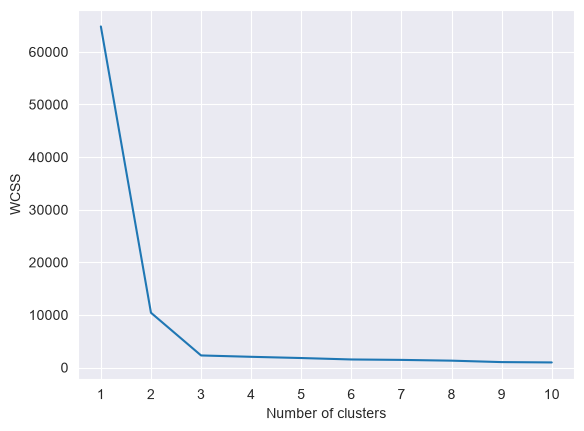

In [16]:
plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## 🚀 7. Nihai Model ve Kümeleme Görselleştirmesi / Final Model & Cluster Visualization

**🇹🇷 Türkçe:**
Dirsek yönteminden yola çıkarak `n_clusters=3` ile `KMeans` **doğru şekilde `X_train_scaled` üzerinde** eğitiliyor, ardından `X_test_scaled` üzerinde küme tahmini yapılıyor (`predict`). Test setindeki noktalar tahmin edilen kümeye göre renklendirilerek saçılım grafiğinde gösteriliyor.

**🇬🇧 English:**
Based on the elbow method, `KMeans` with `n_clusters=3` is trained **correctly on `X_train_scaled`** this time, then used to predict cluster assignments (`predict`) on `X_test_scaled`. Test-set points are plotted on a scatter plot colored by their predicted cluster.

In [17]:
kmeans = KMeans(n_clusters=3, init='k-means++')

In [18]:
kmeans.fit(X_train_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)",

In [19]:
y_pred = kmeans.predict(X_test_scaled)

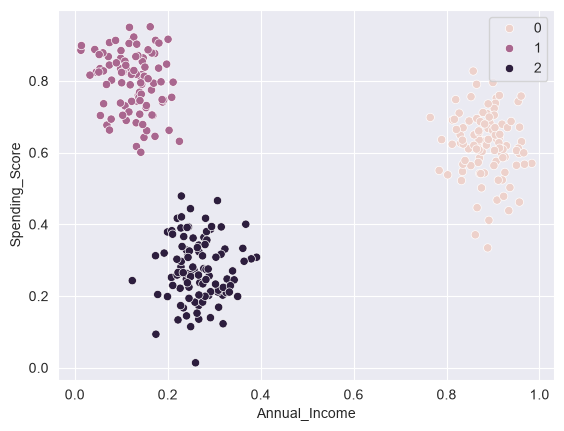

In [20]:
sns.scatterplot(pd.DataFrame(X_test_scaled, columns = X_test.columns), x="Annual_Income", y="Spending_Score", hue=y_pred)
plt.show()

## 🤖 8. Otomatik Dirsek Tespiti / Automatic Elbow Detection

**🇹🇷 Türkçe:**
Dirsek noktasını gözle tahmin etmek yerine, `kneed` kütüphanesinin `KneeLocator`'ı WCSS eğrisi üzerinde programatik olarak çalıştırılıyor (`curve="convex", direction="decreasing"` — WCSS eğrisinin şekliyle uyumlu). Sonuç: `kl.elbow = 3`, yukarıdaki görsel tahmini doğruluyor (bu değerin de, önceki hücredeki ölçeklenmemiş WCSS listesinden hesaplandığını unutmamak gerekir).

**🇬🇧 English:**
Instead of eyeballing the elbow point, `kneed`'s `KneeLocator` runs programmatically on the WCSS curve (`curve="convex", direction="decreasing"` — matching the WCSS curve's shape). Result: `kl.elbow = 3`, confirming the visual estimate above (worth remembering this value is still computed from the unscaled WCSS list from the earlier cell).

In [21]:
from kneed import KneeLocator

In [22]:
kl = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")

In [23]:
kl.elbow

np.int64(3)

## ✅ 9. Silüet Skoru ile Doğrulama / Validation with Silhouette Score

**🇹🇷 Türkçe:**
Silüet skoru (silhouette score), her noktanın kendi kümesine ne kadar iyi uyduğunu (kendi kümesine olan ortalama uzaklık ile en yakın komşu kümeye olan uzaklığı karşılaştırarak) ölçüyor; +1'e yakın değerler iyi ayrılmış kümelere işaret ediyor. Bu kez döngü **doğru şekilde `X_train_scaled`** üzerinde çalışıyor. k=2'den 10'a kadar hesaplanan skorlar arasında en yüksek değer **k=3'te 0.7857** — k=2'deki 0.6538'i ve k=4'teki 0.6401'i açık farkla geçiyor.

**Sonuç:** Dirsek yöntemi (ölçeksiz veriyle, hatalı) ve silüet skoru (ölçekli veriyle, doğru) birbirinden bağımsız iki yöntem olmasına rağmen aynı k=3 sonucuna varıyor — bu da nihai modelin seçimini güçlendiriyor, ama bu iki yöntemin aynı ölçekli veri üzerinde tutarlı şekilde koşturulması (yukarıdaki notta belirtildiği gibi) daha sağlam bir kanıt olurdu.

**🇬🇧 English:**
The silhouette score measures how well each point fits its own cluster (comparing its average distance to points in its own cluster against the distance to the nearest neighboring cluster); values close to +1 indicate well-separated clusters. This time the loop correctly runs on **`X_train_scaled`**. Among scores computed for k=2 to 10, the highest is **0.7857 at k=3** — clearly ahead of 0.6538 at k=2 and 0.6401 at k=4.

**Conclusion:** The elbow method (on unscaled data, buggy) and the silhouette score (on scaled data, correct) are two independent methods, yet they arrive at the same k=3 — which strengthens confidence in the final model choice, though running both methods consistently on the same scaled data (as noted above) would have been more rigorous evidence.

In [24]:
from sklearn.metrics import silhouette_score

In [25]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_scores.append(score)



In [26]:
silhouette_scores

[0.6538372460771634,
 0.7856941696336582,
 0.6400963431308931,
 0.5110353307041757,
 0.47046257389298773,
 0.373041026622574,
 0.3515654585380606,
 0.36074866886001894,
 0.3452110301615201]

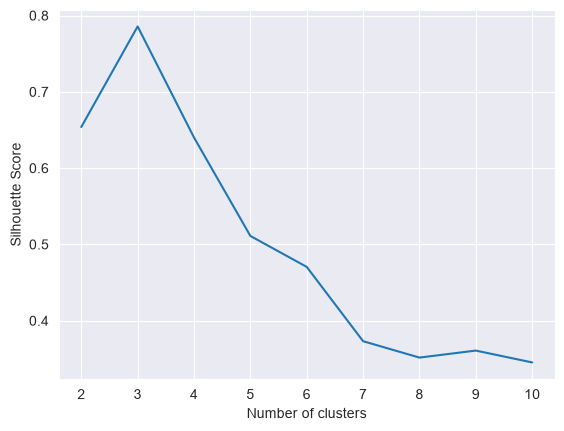

In [28]:
plt.plot(range(2, 11), silhouette_scores)
plt.xticks(range(2, 11))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()